In [17]:
import sys
sys.path.append('../')
import os.path as osp

import torch
from torch.utils.data import DataLoader
import numpy as np
import copy
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import utils
import utils.Camel.equations as equations

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


# Now create a combined model and optimize the coefficients

In [18]:
SAVE_DIR = "./models"
DATA_DIR = "./data"

In [19]:
batch_size = int(2**8)
subdensity_model_paths = [osp.join(SAVE_DIR, "classifier_subdensity_{}_batch{}.zip".format(i+1, batch_size)) for i in range(4)]

In [20]:
FINE_TUNE = True

mix_model = utils.models.MixtureClassifier(subdensity_model_paths, fine_tune=FINE_TUNE).to(DEVICE)
print(mix_model)

MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


In [21]:
source_file = osp.join(DATA_DIR, "base_distribution_mc_data")
target_file = osp.join(DATA_DIR, "target_distribution_mc_data")

source_positive_file = source_file + "_positives"
source_negative_file = source_file + "_negatives"
target_positive_file = target_file + "_positives"
target_negative_file = target_file + "_negatives"

files = [source_positive_file, source_negative_file, target_positive_file, target_negative_file]

sum_weights = []
for f in files:
    sum_weights.append(np.load(f + "_train.npy")[:,-1].sum())

sum_weights = np.array(sum_weights)
sum_weights

array([1600782., -399218., 1334428., -665572.])

In [22]:
coefficient_init = [sum_weights[0] / sum_weights[:2].sum(), sum_weights[2] / sum_weights[2:].sum()]
coefficient_init

[np.float64(1.3322486359444856), np.float64(1.9950901240326766)]

In [23]:
mix_model.initialize(coefficient_init)
list(mix_model.parameters())

[Parameter containing:
 tensor(1.3322, requires_grad=True),
 Parameter containing:
 tensor(1.9951, requires_grad=True),
 Parameter containing:
 tensor([[ 0.0222,  0.2294],
         [-0.6252, -0.5125],
         [-0.3643,  0.2454],
         [-0.0085,  0.5826],
         [-0.0160,  0.1452],
         [-0.1609, -0.1426],
         [-0.7256, -0.4523],
         [-0.3090,  0.0909],
         [ 0.2491,  0.4755],
         [-0.4400, -0.3366],
         [ 0.2199,  0.6379],
         [-0.1293,  0.4677],
         [-0.0564,  0.0472],
         [ 0.7278, -0.7119],
         [-0.4476, -0.1734],
         [-0.3751,  0.6699],
         [-0.4910, -0.3681],
         [-0.5040, -0.6574],
         [-0.4661,  0.6043],
         [ 0.3921,  0.3837],
         [-0.0037, -0.3635],
         [ 0.1510, -0.6944],
         [-0.5311, -0.3851],
         [ 0.5219,  0.4040],
         [-0.2051, -0.0575],
         [ 0.5019,  0.7222],
         [ 0.2529,  0.0384],
         [ 0.4641, -0.3766],
         [ 0.1412, -0.4382],
         [-0.385

In [24]:
training_settings_mix = {}

source_mixture_coef = (4, -1)
source_scales = (2.5, 2.3)
target_mixture_coef = (2, -1)
target_scales = (2, 1.2)


MIN_TRAIN_SIZE = int(min([np.load(source_file + "_train.npy").shape[0], np.load(target_file + "_train.npy").shape[0]]))
MIN_VALID_SIZE = int(min([np.load(source_file + "_val.npy").shape[0], np.load(target_file + "_val.npy").shape[0]]))

train_base_dataset = utils.preprocessing.Dataset(source_file + "_train.npy", 0, stop_event=MIN_TRAIN_SIZE)
valid_base_dataset = utils.preprocessing.Dataset(source_file + "_val.npy", 0, stop_event=MIN_VALID_SIZE)

train_target_dataset = utils.preprocessing.Dataset(target_file + "_train.npy", 1, stop_event=MIN_TRAIN_SIZE)
valid_target_dataset = utils.preprocessing.Dataset(target_file + "_val.npy", 1, stop_event=MIN_VALID_SIZE)

training_settings_mix.update({
    "source_file": source_file,
    "target_file": target_file,
    "source_mixture_coef": source_mixture_coef,
    "source_scales": source_scales,
    "target_mixture_coef": target_mixture_coef,
    "target_scales": target_scales
})

In [25]:
source_weight_norm = train_base_dataset.process(normalize_weights=True)
valid_base_dataset.process(normalize_weights=True)

target_weight_norm = train_target_dataset.process(normalize_weights=True)
valid_target_dataset.process(normalize_weights=True)

tensor(0.3339)

In [26]:
train_generator_data = utils.preprocessing.CombinedDataset(train_base_dataset, train_target_dataset)
valid_generator_data = utils.preprocessing.CombinedDataset(valid_base_dataset, valid_target_dataset)

In [27]:
X_scaler, train_weight_norm = utils.preprocessing.get_scaling(train_generator_data)
_, valid_weight_norm = utils.preprocessing.get_scaling(valid_generator_data)
print(train_weight_norm, valid_weight_norm)

100%|██████████| 1172/1172 [00:04<00:00, 256.63it/s]

tensor(1.0000) tensor(1.0000)


### Save the plain SMM model

In [ ]:
SAVE_SMM = False

if SAVE_SMM:
    SMM_model = utils.models.MixtureClassifier(subdensity_model_paths, t0=t0, t1=t1, fine_tune=False).to(DEVICE)
    SMM_model.initialize(coefficient_init)
    model_name = "classifier_SMM_batch{}".format(batch_size)
    model_metadata = utils.train.get_model_metadata(training_settings_mix, SMM_model, X_scaler, train_weight_norm)
    utils.train.save_model_data(SMM_model, model_metadata, savedir=SAVE_DIR, name=model_name, save_onnx=False, device=DEVICE)

### Now optimize the coefficients

In [29]:
random_seed = 0

torch.manual_seed(random_seed)

train_loader = DataLoader(train_generator_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_generator_data, batch_size=batch_size, shuffle=False)

In [30]:
learning_rate = 1e-4
optimizer = torch.optim.Adam(mix_model.parameters(), lr=learning_rate)

# Get the analytical optimal classifier
def qdre_score_function(ratio):
    return (ratio + 2 - np.sqrt(ratio**2 + 4)) / (2*ratio)

r_optimal = equations.optimal_likelihood_ratio(source_mixture_coef, source_scales, target_mixture_coef, target_scales)
s_optimal = lambda x: qdre_score_function(r_optimal(x))

if FINE_TUNE is False:
    model_name = "classifier_SMMc_revert_batch{}".format(batch_size)
else:
    model_name = "classifier_SMMr_revert_batch{}".format(batch_size)

In [31]:
n_epochs = 1500
stale_epochs = 0
best_valid_loss = 99999
patience = 10
max_num_batches = int(int(1e5) / batch_size)
t = tqdm(range(0, n_epochs))

training_losses = [utils.train.test(
        mix_model,
        train_loader,
        weight_norm=train_weight_norm,
        loss='revert',
        SMM=True,
        device=DEVICE,
        max_num_batches=max_num_batches,
        progress_bar=False,
        leave=False
    )[0],]
validation_losses = [utils.train.test(
        mix_model,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='revert',
        SMM=True,
        device=DEVICE,
        progress_bar=False,
        leave=False
    )[0],]

optimal_train_loss = utils.train.get_optimal_loss(
        s_optimal,
        train_loader,
        weight_norm=train_weight_norm,
        loss='revert',
        device=DEVICE,
        progress_bar=False
)
optimal_valid_loss = utils.train.get_optimal_loss(
        s_optimal,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='revert',
        device=DEVICE,
        progress_bar=False
)

training_settings_mix.update({
    "optimal_train_loss": optimal_train_loss,
    "optimal_valid_loss": optimal_valid_loss
})

for epoch in t:
    loss = utils.train.train(
        mix_model,
        optimizer,
        train_loader,
        weight_norm=train_weight_norm,
        max_num_batches=max_num_batches,
        loss='revert',
        SMM=True,
        device=DEVICE,
        progress_bar=False,
        leave=bool(epoch == n_epochs - 1),
    )
    #loss -= optimal_train_loss
    training_losses.append(loss[0])

    valid_loss = utils.train.test(
        mix_model,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='revert',
        SMM=True,
        device=DEVICE,
        progress_bar=False,
        leave=bool(epoch == n_epochs - 1),
    )
    #valid_loss -= optimal_valid_loss
    validation_losses.append(valid_loss[0])
    print("Epoch: {:02d}, Training Loss:   {:.4f}".format(epoch, loss[1]))
    print("           Validation Loss: {:.4f}".format(valid_loss[1]))

    if valid_loss[1] < best_valid_loss:
        best_valid_loss = valid_loss[1]
        print("New best model with parameters:", mix_model.coefficients)
        training_settings_mix.update({
            "n_epochs": epoch+1,
            "training_losses": training_losses,
            "validation_losses": validation_losses
        })
        model_metadata = utils.train.get_model_metadata(training_settings_mix, mix_model, X_scaler, train_weight_norm)
        utils.train.save_model_data(mix_model, model_metadata, savedir=SAVE_DIR, name=model_name, save_onnx=False, device=DEVICE)
        print("New best model saved to: {}.zip".format(osp.join(SAVE_DIR, model_name)))
        stale_epochs = 0
    else:
        print("Stale epoch")
        stale_epochs += 1
    if stale_epochs >= patience:
        print("Early stopping after %i stale epochs" % patience)
        break

  0%|          | 0/1500 [00:00<?, ?it/s]

/tmp/ipykernel_146587/2960889082.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return (ratio + 2 - np.sqrt(ratio**2 + 4)) / (2*ratio)


Epoch: 00, Training Loss:   0.8933
           Validation Loss: 0.8988
New best model with parameters: (1.3279005289077759, 1.9969661235809326)
New best model saved to: ./models/classifier_SMMr_revert_batch256.zip
Epoch: 01, Training Loss:   0.8959
           Validation Loss: 0.8986
New best model with parameters: (1.3214435577392578, 1.9945242404937744)
New best model saved to: ./models/classifier_SMMr_revert_batch256.zip
Epoch: 02, Training Loss:   0.8943
           Validation Loss: 0.8986
New best model with parameters: (1.3147414922714233, 1.995526909828186)
New best model saved to: ./models/classifier_SMMr_revert_batch256.zip
Epoch: 03, Training Loss:   0.8931
           Validation Loss: 0.8987
Stale epoch
Epoch: 04, Training Loss:   0.9033
           Validation Loss: 0.8986
Stale epoch
Epoch: 05, Training Loss:   0.9032
           Validation Loss: 0.8987
Stale epoch
Epoch: 06, Training Loss:   0.9064
           Validation Loss: 0.8986
Stale epoch
Epoch: 07, Training Loss:   0.8921

## Look at the loss curves

Text(0, 0.5, 'BCE Loss')

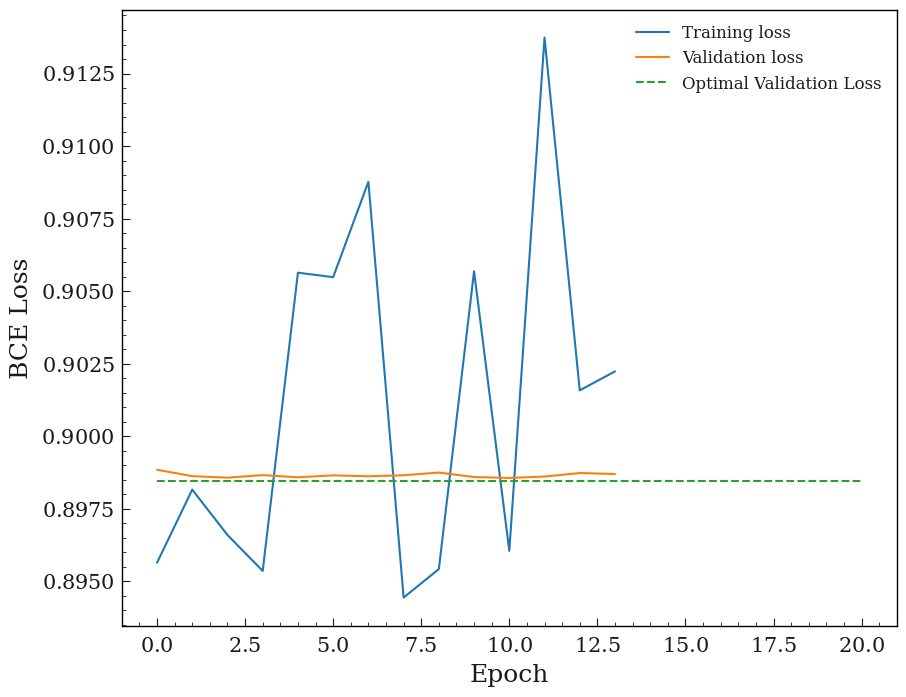

In [32]:
fig,ax = plt.subplots()
fig.set_size_inches(10, 8)

starting_epoch = 1
training_loss_per_epoch = np.array(training_losses[starting_epoch:]).mean(axis=1)
training_std_per_epoch = np.array(training_losses[starting_epoch:]).std(axis=1)

validation_loss_per_epoch = np.array(validation_losses[starting_epoch:]).mean(axis=1)
validation_std_per_epoch = np.array(validation_losses[starting_epoch:]).std(axis=1)

training_lower_bar = training_loss_per_epoch - training_std_per_epoch
training_upper_bar = training_loss_per_epoch + training_std_per_epoch

validation_lower_bar = validation_loss_per_epoch - validation_std_per_epoch
validation_upper_bar = validation_loss_per_epoch + validation_std_per_epoch


t1 = np.arange(len(training_loss_per_epoch))
t2 = np.arange(len(validation_loss_per_epoch))
ax.plot(t1, training_loss_per_epoch, '-', label="Training loss", c='tab:blue')
#ax.fill_between(t1, training_lower_bar, training_upper_bar, color='tab:blue', alpha=0.30)

ax.plot(t2, validation_loss_per_epoch, '-', label="Validation loss", c='tab:orange')
#ax.fill_between(t2, validation_lower_bar, validation_upper_bar, color='tab:orange', alpha=0.30)

ax.plot([0, max([t1.max(), t2.max()])], [training_settings_mix["optimal_valid_loss"]]*2, '--', color='tab:green', label="Optimal Validation Loss")
#ax.plot([0, max([t1.max(), t2.max()])], [training_settings_mix["optimal_train_loss"]]*2, '--', color='tab:green', label="Optimal Training Loss")

#ax.set_xscale('log')
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")